In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science"])

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    "text.usetex": True,        
    "font.family": "serif",     
    "font.serif": ["Times"],
    "figure.dpi": 300,          
    "axes.grid": True,          
    "grid.linestyle": "--",     
})

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from multiprocessing import Pool
import time
import torch
from scipy.ndimage import gaussian_filter
from ds_utils import  *
from ps_utils import  *

In [4]:
DATA_DIR = Path("/pscratch/sd/k/kp22/deft/")

# Flat sky

In [5]:
RES = 256
STEP_SIZE = 6. 
ANG_X = 6. 
ANG_Y = 6. 
flatskymapparams = [RES, RES, 60.*ANG_X/RES, 60.*ANG_X/RES] #Needs pixelres to be in arcmin
nx,ny,dx,dy = flatskymapparams
dx_rad = np.radians(dx/60.)
dy_rad = np.radians(dy/60.)
lx, ly = get_lxly(flatskymapparams)
ell_grid = np.sqrt(lx**2 + ly**2)

In [6]:
n_samples = 801

In [7]:
def bandpass_filter(map_i, l_c, delta_l):
    """ Filter the map in Fourier space to only include a band around l_c with width delta_l """
    fft_map = fft2(map_i)
    mask = (ell_grid >= (l_c - delta_l/2)) & (ell_grid <= (l_c + delta_l/2))
    fft_map *= mask
    return ifft2(fft_map).real

In [8]:
def compute_statistics(map_i):
    """ Compute the variance, skewness, and kurtosis of the map """
    mean_subtracted_map = map_i - np.mean(map_i)
    S2 = np.mean(mean_subtracted_map**2)
    S3 = np.mean(mean_subtracted_map**3) 
    S4 = np.mean(mean_subtracted_map**4) - 3 * S2**2
    return S2, S3, S4

In [9]:
def compute_statistics_per_band(maps, band_centers, delta_l,apo=True):
    moments_data = np.empty((len(maps), len(band_centers), 3))
    if apo:
        apo_radius = 55
        apo_shape = "square"
        print(f"Using apodization of: {apo_radius} and shape {apo_shape}")
    else: 
        apo_radius = 0
        apo_shape = "square"
    apo_mask = get_apodised_mask(flatskymapparams,apo_radius, mask=apo_shape)
    for i in range(len(maps)): 
        if i%200 == 0: print(f"{i}/{len(maps)}")
        map_data = np.where(apo, maps[i, :, :, 0] * apo_mask, maps[i, :, :, 0])
        for j,center in enumerate(band_centers):            
            filtered_map = bandpass_filter(map_data, center, delta_l)
            S2, S3, S4 = compute_statistics(filtered_map)

            moments_data[i][j][0] = S2
            moments_data[i][j][1] = S3
            moments_data[i][j][2] = S4
            
    return moments_data

In [10]:
def get_apodised_mask(mapparams, boundary_radius_am, mask = 'circle'):

    import numpy as np, scipy.ndimage as ndimage, scipy.signal as signal
    nx, ny, dx, dy = mapparams

    pix = dx
    radius = (nx * pix)/10.
    npix_cos = int(radius/pix)
    ker=np.hanning(npix_cos)
    ker2d=np.asarray( np.sqrt(np.outer(ker,ker)) )

    apod_mask=np.zeros((nx,ny))
    minval, maxval = -(nx*pix)/2,  (nx*pix)/2
    x = y = np.linspace(minval, maxval, nx)
    X, Y = np.meshgrid(x,y)
    xc, yc = 0., 0.
    if mask=='circle':
        inds=np.where((X-xc)**2. + (Y-yc)**2. <= boundary_radius_am**2.) #all in arcmins
    elif mask=='square':
        inds=np.where((abs(X-xc) <= boundary_radius_am) & (abs(Y-yc) <= boundary_radius_am)) #all in arcmins
    apod_mask[inds]=1.
    
    apod_mask=ndimage.convolve(apod_mask, ker2d)
    apod_mask/=apod_mask.max()
    return apod_mask

In [11]:
lmin = 300
lmax = 6000
delta_l = 720
bandpass_edges = np.arange(lmin, lmax, delta_l)
bandpass_centers = (bandpass_edges[:-1] + bandpass_edges[1:]) // 2

In [12]:
RES = 256
STEP_SIZE = 6. * u.deg
ANG_X = 6. * u.deg
ANG_Y = 6. * u.deg
flatskymapparams = [RES, RES, 60.*ANG_X.value/RES, 60.*ANG_Y.value/RES] #Code requires pixelres to be in arcmin

In [13]:
#fpath = "data/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_log.npy"
fpath = "data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz.npy"
print(fpath)
cut_maps = np.load(fpath)
print("Total Maps = : ", len(cut_maps))
num_samples = len(cut_maps)

data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz.npy
Total Maps = :  1041


In [14]:
num_train = int(0.8 * num_samples)
rng = np.random.default_rng(seed=42)
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]
test_indices = indices[num_train:]
training_images = cut_maps[train_indices]
testing_images = cut_maps[test_indices]

In [36]:
training_images[:n_samples].shape

(801, 256, 256, 1)

In [15]:
moments_data_train = compute_statistics_per_band(training_images[:n_samples], bandpass_centers,delta_l,apo=False)

/tmp/ipykernel_1805949/702608922.py:24: RuntimeWarning: invalid value encountered in divide
  apod_mask/=apod_mask.max()


0/801
200/801
400/801
600/801
800/801


In [16]:
moments_data_test = compute_statistics_per_band(testing_images[:n_samples], bandpass_centers,delta_l,apo=False)

0/209


/tmp/ipykernel_1805949/702608922.py:24: RuntimeWarning: invalid value encountered in divide
  apod_mask/=apod_mask.max()


200/209


In [17]:
np.save("data/low_pass/2mJy/moments_train_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy",moments_data_train)
np.save("data/low_pass/2mJy/moments_test_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy",moments_data_test)

In [19]:
fpath = "data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_tsz.npy"
cut_maps = np.load(fpath)

In [20]:
moments_data_gaussian = compute_statistics_per_band(cut_maps[:n_samples], bandpass_centers,delta_l,apo=False)

/tmp/ipykernel_1805949/702608922.py:24: RuntimeWarning: invalid value encountered in divide
  apod_mask/=apod_mask.max()


0/801
200/801
400/801
600/801
800/801


In [30]:
np.save("data/low_pass/2mJy/moments_gaussian_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy",moments_data_gaussian)

In [26]:
all_samples = np.load("data/low_pass/2mJy/new_samples_12_cib_tsz_2mJy_zero_norm_6x6_w_au_lp.npy")[:,1,:,:]
all_samples = all_samples[:, np.newaxis, :, :]

In [27]:
all_samples.shape

(960, 1, 256, 256)

In [28]:
#all_samples *= 224.06384 #110.732285
#all_samples = ((all_samples - np.mean(all_samples))*(np.std(cut_maps)/np.std(all_samples))) + np.mean(all_samples)
all_samples *= 102.28776
all_samples -= 102.28776
all_samples = ((all_samples - np.mean(all_samples))*(np.std(cut_maps)/np.std(all_samples))) + np.mean(all_samples)

all_samples = all_samples.transpose(0,2,3,1)

In [29]:
moments_samples  = compute_statistics_per_band(all_samples[:n_samples], bandpass_centers,delta_l,apo=False)

/tmp/ipykernel_1805949/702608922.py:24: RuntimeWarning: invalid value encountered in divide
  apod_mask/=apod_mask.max()


0/801
200/801
400/801
600/801
800/801


In [31]:
np.save("data/low_pass/2mJy/moments_samples_2mJy_deltaell_720_200rlz_6x6_lp_curve_tsz.npy",moments_samples)

In [33]:
def load_moments(filename,max_lines=-1):
    moments_data = np.load(filename)[:max_lines]
    moments={}
    moments["variances"] = [m/bandpass_centers for m in moments_data[:,:,0]]
    moments["skewnesses"] = [m/bandpass_centers for m in moments_data[:,:,1]]
    moments["kurtoses"] = [m/bandpass_centers**2 for m in moments_data[:,:,2]]
    return moments

In [42]:
np.mean(moments_data_train["skewnesses"],axis=0)

array([-3.58889737e-04, -3.67288423e-05, -1.20682474e-05, -5.69068154e-06,
       -3.02950641e-06, -1.73180265e-06, -1.04951763e-06])

In [43]:
np.mean(moments_samples["skewnesses"],axis=0)

array([-3.32868198e-04, -3.96689233e-05, -1.41425960e-05, -6.63497490e-06,
       -3.45624475e-06, -1.89433090e-06, -1.13670565e-06])

In [34]:
moments_data_train = load_moments("data/low_pass/2mJy/moments_train_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy")
moments_data_test = load_moments("data/low_pass/2mJy/moments_test_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy")
moments_samples = load_moments("data/low_pass/2mJy/moments_samples_2mJy_deltaell_720_200rlz_6x6_lp_curve_tsz.npy")
moments_data_gaussian = load_moments("data/low_pass/2mJy/moments_gaussian_2mJy_deltaell_720_200rlz_6x6_lp_tsz.npy")

# Plotting

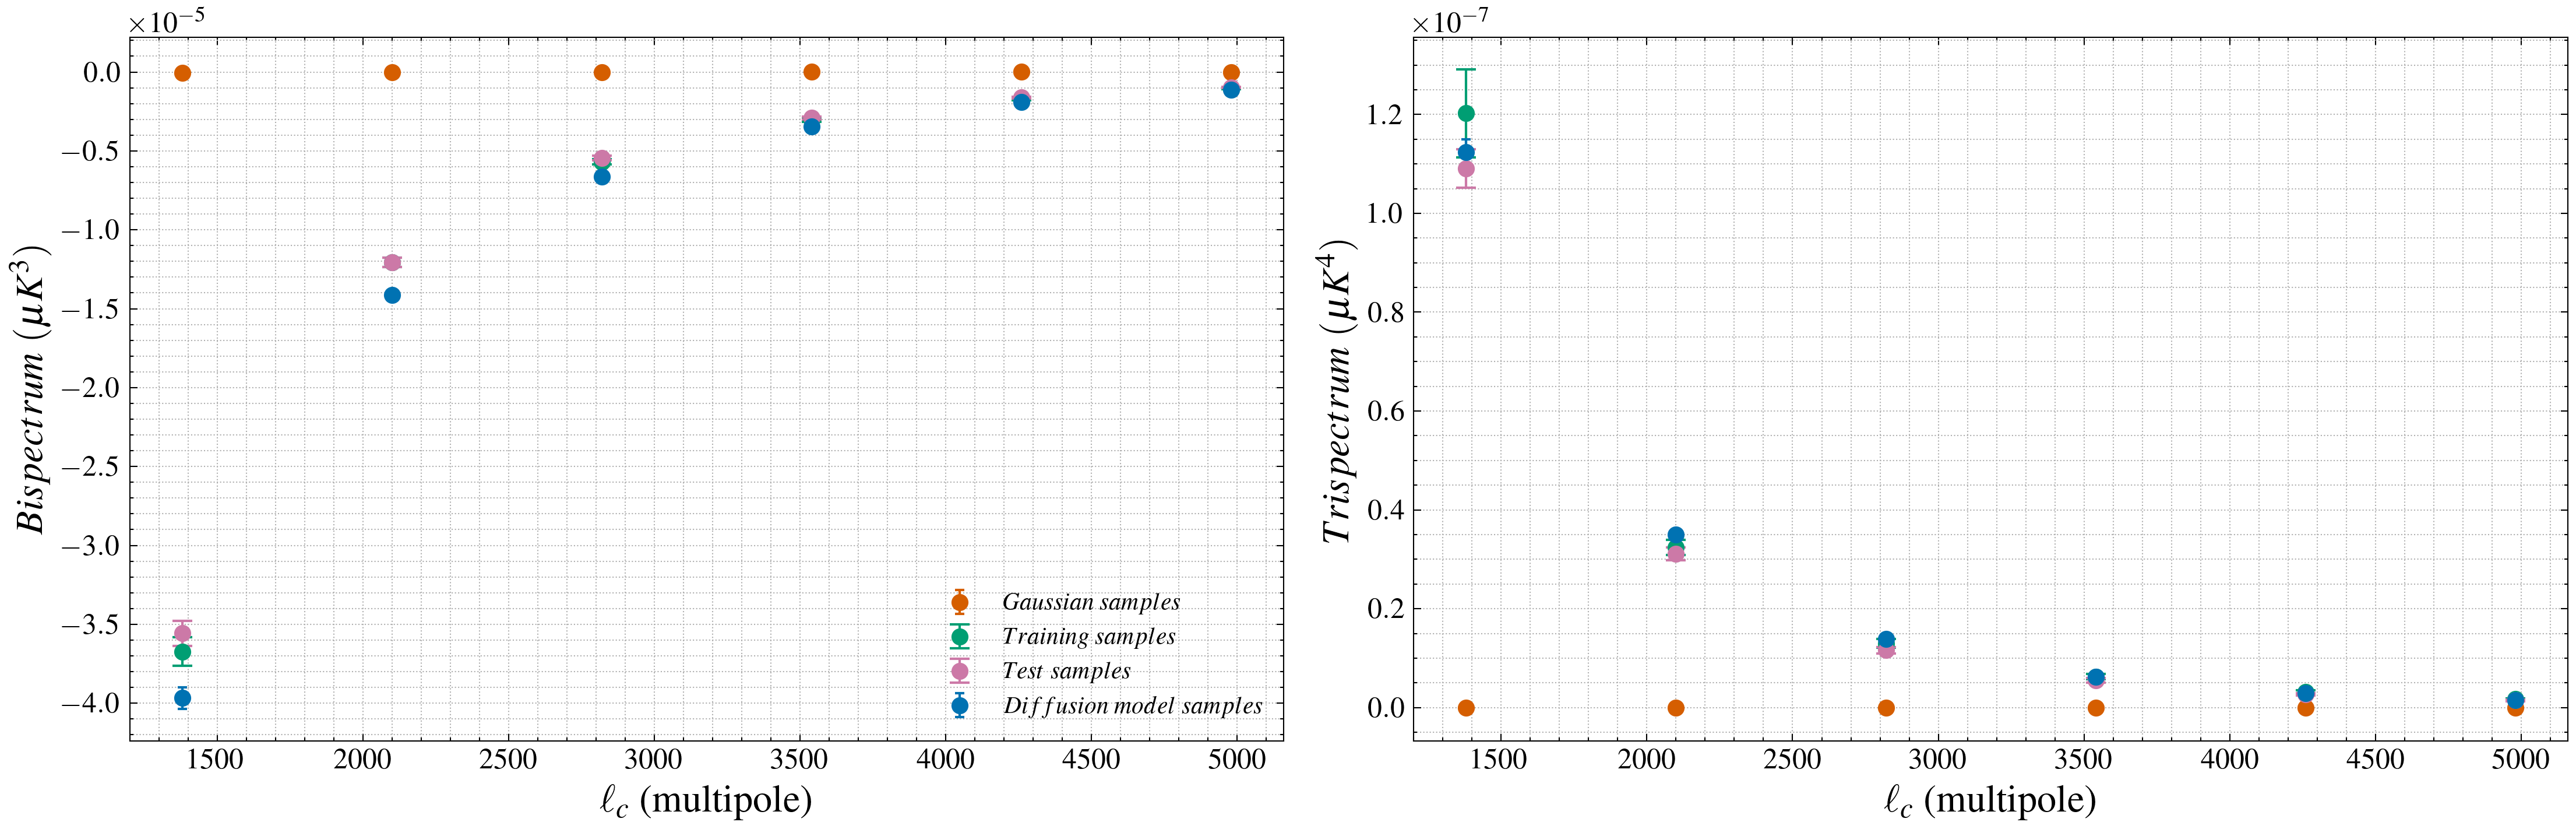

In [35]:
exclude_n = 1
fsval = 16
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_gaussian["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_gaussian["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#D55E00", label=r"$Gaussian\ samples$")
axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_train["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_train["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#009E73", label=r"$Training\ samples$")
axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_test["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_test["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#CC79A7", label=r"$Test\ samples$")
axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_samples["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_samples["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#0072B2", label=r"$Diffusion\ model\ samples$")
axes[0].set_xlabel(r'$\ell_c$ (multipole)', fontsize=fsval)
axes[0].set_ylabel(r'$Bispectrum\ (\mu K^3)$', fontsize=fsval)
axes[0].grid(True, which='both', ls=':', lw=0.5)
axes[0].legend(fontsize=10)

axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_gaussian["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_gaussian["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#D55E00", label=r"$Gaussian\ samples$")
axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_train["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_train["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#009E73", label=r"$Training\ samples$")
axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_test["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_test["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#CC79A7", label=r"$Test\ samples$")
axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_samples["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_samples["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#0072B2", label=r"$Diffusion\ model\ samples$")
axes[1].set_xlabel(r'$\ell_c$ (multipole)', fontsize=fsval)
axes[1].set_ylabel(r'$Trispectrum\ (\mu K^4)$', fontsize=fsval)
# axes[1].set_xscale('log')
axes[1].grid(True, which='both', ls=':', lw=0.5)
#axes[1].legend(fontsize=10)

plt.tight_layout()
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_curve.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_curve.png", dpi=200, bbox_inches="tight")
plt.show()
